# Link do materiałów:
 https://en.wikipedia.org/wiki/K-means_clustering  
 Dane:  
 https://www.kaggle.com/datasets/thedevastator/predicting-credit-card-customer-attrition-with-m

# Zaczytać dane i doprowadzić do postaci numerycznej (dummy)

In [ ]:
!kaggle datasets download thedevastator/predicting-credit-card-customer-attrition-with-m

Dataset URL: https://www.kaggle.com/datasets/thedevastator/predicting-credit-card-customer-attrition-with-m
License(s): CC0-1.0
  0% 0.00/379k [00:00<?, ?B/s]
100% 379k/379k [00:00<00:00, 27.2MB/s]


In [ ]:
!unzip predicting-credit-card-customer-attrition-with-m.zip

Archive:  predicting-credit-card-customer-attrition-with-m.zip
  inflating: BankChurners.csv        


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('BankChurners.csv')

# Zadanie: usunąć kolumny:  
CLIENTNUM: Unique identifier for each customer. (Integer)  
Attrition_Flag: Flag indicating whether or not the customer has churned out. (Boolean)

In [ ]:
drop_columns = ['CLIENTNUM',
                'Attrition_Flag',
                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
]

In [ ]:
df.drop(drop_columns, axis=1, inplace=True)

In [ ]:
df_numeric = pd.get_dummies(df, drop_first=True)

In [ ]:
df_numeric

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,False,False,False,True,False,False,False,False,False,False
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,True,False,False,False,False,True,False,False,False,False
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,False,False,False,False,True,False,False,False,False,False
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,False,True,False,False,False,True,False,False,False,False
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,50,2,40,3,2,3,4003.0,1851,2152.0,0.703,...,True,False,True,False,False,False,False,False,False,False
10123,41,2,25,4,2,3,4277.0,2186,2091.0,0.804,...,False,False,True,False,False,False,False,False,False,False
10124,44,1,36,5,3,4,5409.0,0,5409.0,0.819,...,False,False,False,False,False,True,False,False,False,False
10125,30,2,36,4,3,3,5281.0,0,5281.0,0.535,...,False,True,True,False,False,False,False,False,False,False


## standaryzacja zmiennych - ważny element przetwarzania danych w klastrowaniu

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
numpy_normalized = scaler.fit_transform(df_numeric)

In [ ]:
numpy_normalized.mean(), numpy_normalized.std()

(-1.6049832211427168e-17, 1.0)

# klastrowanie

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
cluster = KMeans(n_clusters=5, random_state=9857)

In [ ]:
cluster.fit(numpy_normalized)

KMeans(n_clusters=5, random_state=9857)

In [ ]:
segments = cluster.predict(numpy_normalized)

In [ ]:
segments.max()

4

## Zadanie: dodać do df, nowe pole, `segments`

In [ ]:
df['segments'] = segments

# Wizualizacje dla segmentów (clusters)

In [ ]:
df.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,segments
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,2
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,1
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,2
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


## Wizualizacje za pomocą scatter plot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

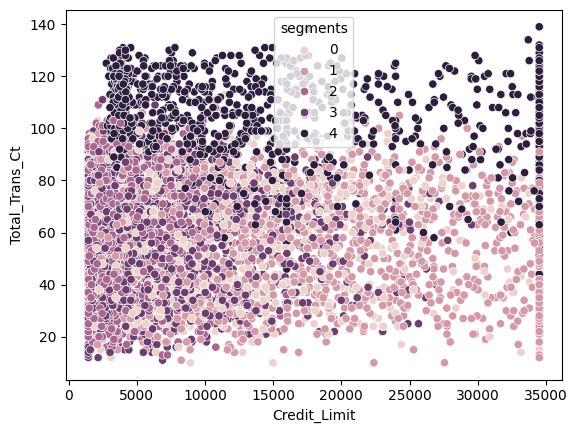

In [ ]:
sns.scatterplot(x='Credit_Limit', y='Total_Trans_Ct', hue='segments', data=df)
plt.show()

In [ ]:
df.columns

Index(['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
       'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'segments'],
      dtype='object')

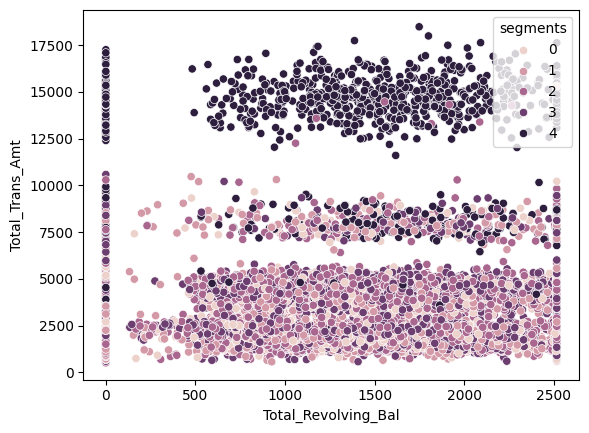

In [ ]:
sns.scatterplot(x='Total_Revolving_Bal', y='Total_Trans_Amt', hue='segments', data=df)
plt.show()

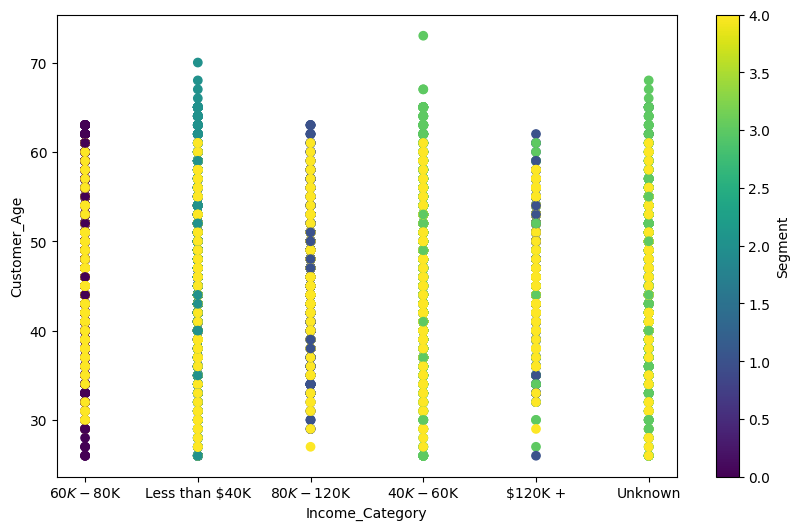

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Income_Category'], df['Customer_Age'], c=df['segments'], cmap='viridis')
plt.xlabel('Income_Category')
plt.ylabel('Customer_Age')
plt.colorbar(label='Segment')
plt.show()

## Wizualizacje za pomocą boxplot

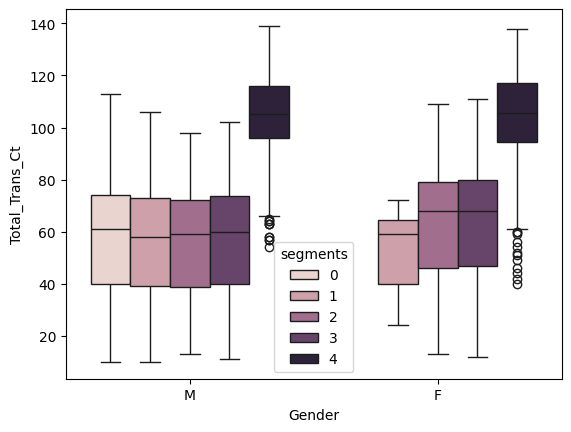

In [ ]:
sns.boxplot(x='Gender', y='Total_Trans_Ct', data=df, hue='segments')
plt.show()

In [ ]:
import matplotlib.pyplot as plt  # subplot
import seaborn as sns

plt.figure(figsize=(16, 10))

columns_for_boxplot = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                        'Total_Relationship_Count', 'Months_Inactive_12_mon',
                        'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
                        'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                        'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

for i, col in enumerate(columns_for_boxplot):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(data=df, x='segments', y=col)
    plt.xlabel('Segments')
    plt.ylabel(col)
    plt.title(f'Box Plot of {col} by Segment')

plt.tight_layout()
plt.show()

## Wizualizacja za pomocą barplot

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


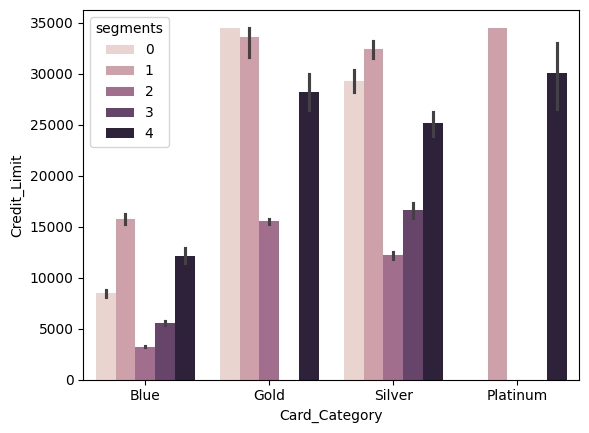

In [ ]:
sns.barplot(x='Card_Category', y='Credit_Limit', hue='segments', data=df)
plt.show()

## Diagram venn:  
https://www.kaggle.com/code/victoriacabrerag/venn-diagram

## Wizualizacja grid:  
https://seaborn.pydata.org/generated/seaborn.FacetGrid.html

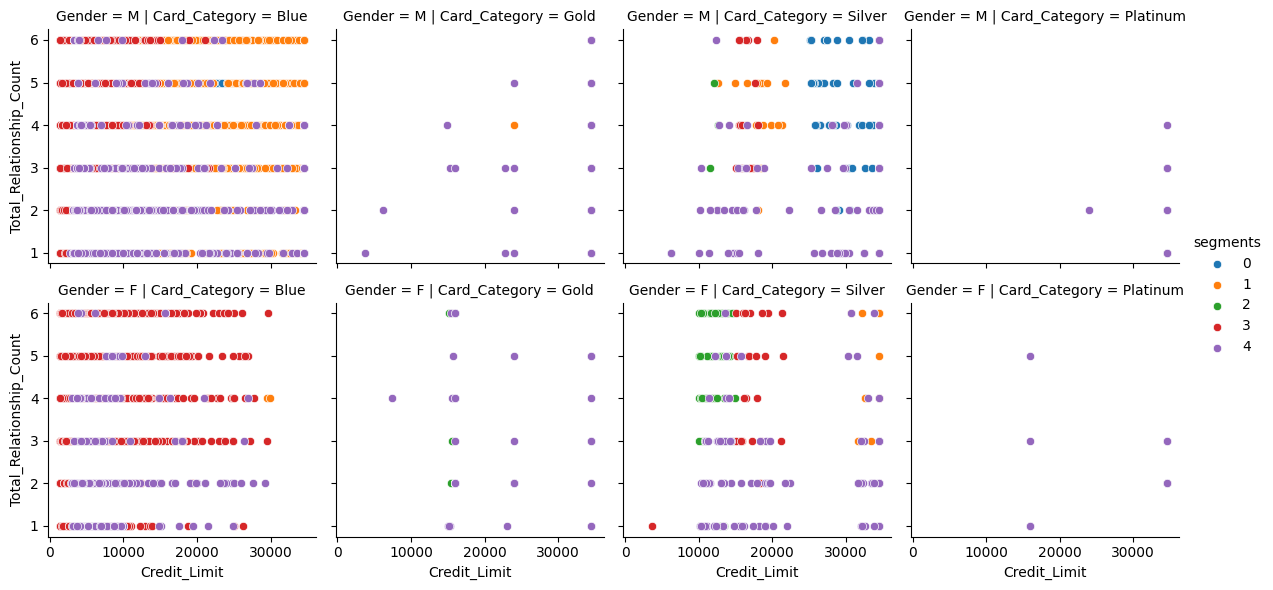

In [ ]:
g = sns.FacetGrid(df, col="Card_Category", row='Gender',  hue="segments")
g.map_dataframe(sns.scatterplot, x="Credit_Limit", y="Total_Relationship_Count")
g.add_legend()

# Analiza doboru liczby klastrów  
wykres łokcia

In [ ]:
cluster = KMeans(n_clusters=200, random_state=9857)
cluster.fit(numpy_normalized)
print(cluster.inertia_)  #

110711.28482698518


### Zadanie utworzyć listę dla cluster.inertia_ dla n od 2 do 100

In [ ]:
inertia_ = [] # n_cluster od 2 do 100
for n in range(2,101):
    cluster = KMeans(n_clusters=n, random_state=9857)
    cluster.fit(numpy_normalized)
    inertia_.append(cluster.inertia_)

In [ ]:
def inertia(n, df):
    cluster = KMeans(n_clusters=n, random_state=9857)
    cluster.fit(df)
    return cluster.inertia_

In [ ]:
inertia_ = [inertia(n, numpy_normalized) for n in range(2, 200)]

In [ ]:
[KMeans(n_clusters=n, random_state=9857).fit(numpy_normalized).inertia_ for n in range(2,5)]  #   list comprehension

[299009.83088309143, 285172.97393689014, 272627.0827259928]

### Zadanie: Wykres (x: liczba klastrów od 1 to 100, y: inertia)

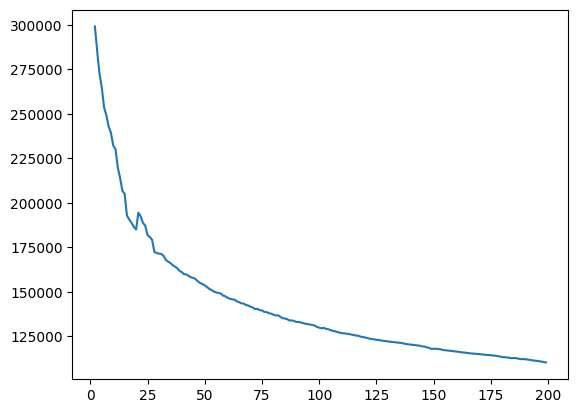

In [ ]:
plt.plot(range(2, 200), inertia_)
plt.show()